# Nearly-Periodic Coupled Oscillators: Training Data Analysis

## Overview

This notebook provides analysis of the HMC-$H_0$ data of the nearly-periodic coupled oscillators (NPCO) problem.

In particular, this notebook will:
1. Generate the naive bounding box (Box) data
2. Load the HMC-$H_0$ data and compare against the Box data
3. Compare the HMC-$H_0$ data flowed by various times and verify the distribution is invariant under the flow 

## Mathematical Model

The system is described by the Hamiltonian:

$$ H_\varepsilon (q_1,q_2,p_1,p_2) = \frac{1}{2} (q_1^2 + p_1^2 ) + \frac{1}{2} \varepsilon (q_2^2 + p_2^2 )  + \varepsilon U(q_1,q_2) $$

where the coupling potential is:
$$ U(q_1,q_2) = q_1 q_2 \sin(2q_1 + 2q_2) $$

The equations of motion are:
$$ \begin{cases} \dot{q}_1 = p_1 \qquad & \dot{p}_1 = -q_1 - \varepsilon \partial_{q_1} U(q_1,q_2) \\ \dot{q}_2 = \varepsilon p_2 \qquad & \dot{p}_2 = -\varepsilon q_2 - \varepsilon \partial_{q_2} U(q_1,q_2)
\end{cases} $$

This system exhibits interesting dynamics with coupling parameter $\varepsilon$ controlling the strength of interaction between the oscillators.

## Setup and Dependencies

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.ndimage import gaussian_filter1d

from notebook_utils.dataprocessing import NCO, NCOTrajectory, NCODataset
from notebook_utils.visualization import NCOVisualizer

Trajectory = NCOTrajectory
Dataset = NCODataset

viz = NCOVisualizer()

## Analysis

### 1. Sample Data Points Uniformly in a Bounding Box

We sample points in three boxes as described in the paper "Approximation of Nearly-Periodic Symplectic Maps via Structure-Preserving Neural Networks" by Valentin Duruisseaux, Joshua W. Burby, and Qi Tang.

In [2]:
def sample_points(bounds, num_points):
    """
    Sample points uniformly within a high-dimensional bounded box.

    Parameters:
        bounds (list of tuples): Each tuple represents the (min, max) bounds of each dimension.
        num_points (int): The number of points to generate.

    Returns:
        np.ndarray: An array of shape (num_points, len(dimensions)) containing the sampled points.
    """
    # Check that all dimensions have a min and max
    assert all(len(d) == 2 for d in bounds), "Each dimension must have a min and max bound"

    # Create an empty array to store the points
    points = np.empty((num_points, len(bounds)))

    # For each dimension, generate random numbers within the given bounds
    for i, (low, high) in enumerate(bounds):
        points[:, i] = np.random.uniform(low, high, num_points)

    return points

In [ ]:
# Points in full [-1.6,1.6]x[-1.6,1.6] window for oscillator 1 
#       and full [-0.9,1.6]x[-1.1,1.1] window for oscillator 2
general_points = sample_points(
    bounds = [(-1.6, 1.6), (-1.1, 1.1), (-1.6, 1.6), (-0.9, 1.6)],  # bounds for p1, p2, q1, q2
    num_points=20000)

# More points for smaller right orbits in [0.6,1.5]x[-0.5,0.5] for oscillator 2
points_small_right_orbits = sample_points(
    bounds = [(-1.6, 1.6), (-0.5, 0.5), (-1.6, 1.6), (0.6, 1.5)],  # bounds for p1, p2, q1, q2
    num_points=20000)

# More points for smaller left orbits in [-0.75,0.75]x[-0.75,0.75] for oscillator 2
points_small_left_orbits = sample_points(
    bounds = [(-1.6, 1.6), (-0.75, 0.75), (-1.6, 1.6), (-0.75, 0.75)],  # bounds for p1, p2, q1, q2
    num_points=20000)
    
# Concatenate all the data
data = np.concatenate((general_points, points_small_right_orbits, points_small_left_orbits), axis=0)

# Rescale the data: v2 = p2/m2 = p2*epsilon
epsilon = 0.01
data *= np.array([1., epsilon, 1., 1.])

# # Save the data
# filepath = "../../data/nco/epsilon=1e-2/202510080008_box_s/inputs/U0.csv"
# if not os.path.exists(filepath):
#     os.makedirs(os.path.dirname(filepath), exist_ok=True)
#     pd.DataFrame(data).to_csv(filepath, index=False, header=["v1", "v2", "x1", "x2"])

Alternatively, sample points uniformly in a larger box (for oscillator 2), in order to encapsulate the entire constant energy surface defined by $H=H_0$. Here, $H_0 = H(v_0, x_0) = H([0,0], [1.5,1.5])$.

In [ ]:
# Points in full [-1.6,1.6]x[-1.6,1.6] window for oscillator 1 
#       and full [-16,16]x[-16,16] window for oscillator 2
general_points = sample_points(
    bounds = [(-1.6, 1.6), (-12, 12), (-1.6, 1.6), (-12, 12)],  # bounds for p1, p2, q1, q2
    num_points=600000)

# Concatenate all the data
data = np.concatenate((general_points, ), axis=0)

# Rescale the data: v2 = p2/m2 = p2*epsilon
epsilon = 0.01
data *= np.array([1., epsilon, 1., 1.])

# # Save the data
# filepath = "../../data/nco/epsilon=1e-2/202510080010_box2/inputs/U0.csv"
# if not os.path.exists(filepath):
#     os.makedirs(os.path.dirname(filepath), exist_ok=True)
#     pd.DataFrame(data).to_csv(filepath, index=False, header=["v1", "v2", "x1", "x2"])

### 2. Compare BoundingBox to HMC-H0

We compare different sampling strategies for generating training data:
- BoundingBox: Uniform sampling in a large box
- BoundingBox-S: Uniform sampling in a small box
- HMC-H0: Hamiltonian Monte Carlo sampling at constant energy

In [ ]:
# Set parameter
epsilon = 0.01

# Define data file paths
data_filepaths = {
    "BoundingBox": "../../data/nco/epsilon=1e-2/202510080010_box/inputs/U0.csv",  # BoundingBox [-16,16]x[-16,16] for oscillator 2
    # "BoundingBox2": "../../data/nco/epsilon=1e-2/202510080010_box2/inputs/U0.csv",  # BoundingBox2 [-12,12]x[-12,12] for oscillator 2
    "BoundingBox-S": "../../data/nco/epsilon=1e-2/202510080008_box_s/inputs/U0.csv",  # BoundingBox-S [-0.9,1.6]x[-1.1,1.1] for oscillator 2
    "HMC-H0": "../../data/nco/epsilon=1e-2/202510071037_rhmc-H0/inputs/U0.csv",  # HMC-H0
}

# Load datasets
datasets = [Dataset.load_from_file(filepath, name=name, epsilon=epsilon) for name, filepath in data_filepaths.items()]
for ds in datasets:
    print(ds)

# Create processor for computing energies
processor = NCO(epsilon=epsilon)

NCODataset(states=States(problem=NCO(epsilon=0.01), shape=(600000, 4)), name=BoundingBox)
NCODataset(states=States(problem=NCO(epsilon=0.01), shape=(60000, 4)), name=BoundingBox-S)
NCODataset(states=States(problem=NCO(epsilon=0.01), shape=(600000, 4)), name=HMC-H0)


In [11]:
# Count the number of points in the small bounded box
bounds = [(-1.6, 1.6), (-0.011, 0.011), (-1.6, 1.6), (-0.9, 1.6)]  # bounds for v1, v2, x1, x2

for ds in datasets:
    print(f"{ds.name}:\t Ratio = {len(ds.select_in_box(bounds)) / len(ds)}")

BoundingBox:	 Ratio = 0.005171666666666666
BoundingBox-S:	 Ratio = 1.0
HMC-H0:	 Ratio = 0.007791666666666666


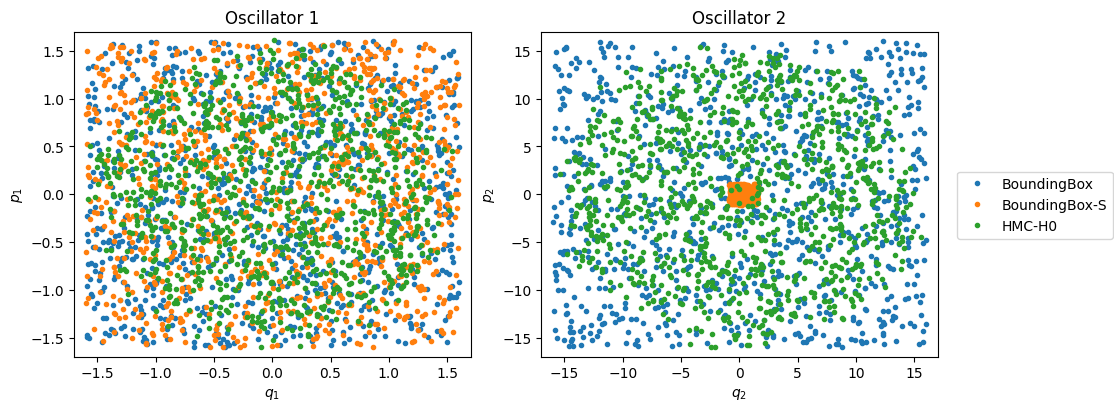

In [12]:
# Plot datasets in the phase space
viz.plot_phase_space(
    [ds.random_samples(1000) for ds in datasets], 
    axis_lims=[((-1.7, 1.7), (-1.7, 1.7)), ((-17, 17), (-17, 17))], 
    alphas=0.3,
    legend_labels=[ds.name for ds in datasets],
    linestyles=['.'] * len(datasets),
    show_legend=True,
    figsize=(11, 4)
)

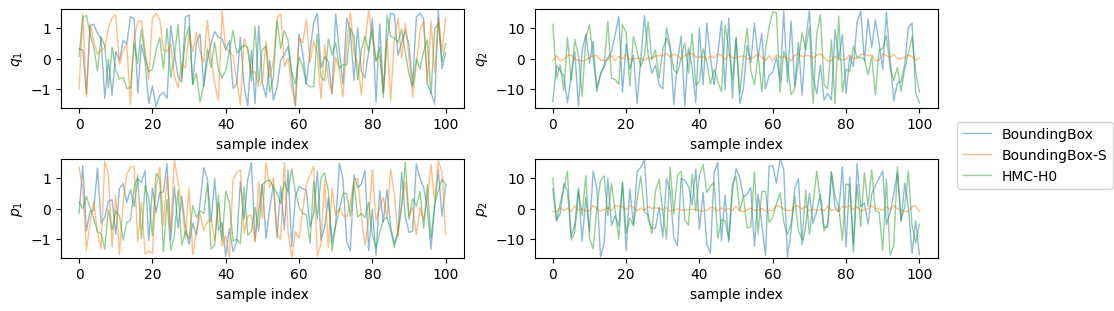

In [13]:
# Plot position and momentum vs sample index
viz.plot_pq_vs_t(
    [ds[:1001:10] for ds in datasets], 
    ylims=[(-1.6, 1.6), (-16, 16), (-1.6, 1.6), (-16, 16)], 
    alpha=0.5,
    legend_labels=[ds.name for ds in datasets],
    show_legend=True,
    xlabel='sample index',
    figsize=(11, 3)
)

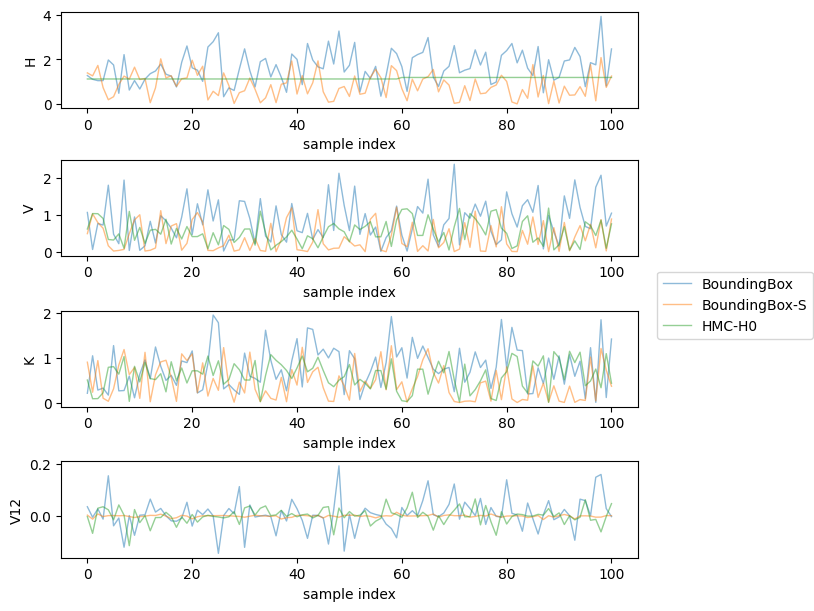

In [14]:
# Plot traces of computed functions
viz.plot_history(
    [ds[:1001:10] for ds in datasets], 
    func_dict={
        "H": processor.compute_hamiltonian,
        "V": processor.compute_potential_energy,
        "K": processor.compute_kinetic_energy,
        "V12": processor.compute_interaction_energy
    },
    alpha=0.5,
    legend_labels=[ds.name for ds in datasets],
    show_legend=True,
    xlabel='sample index'
)

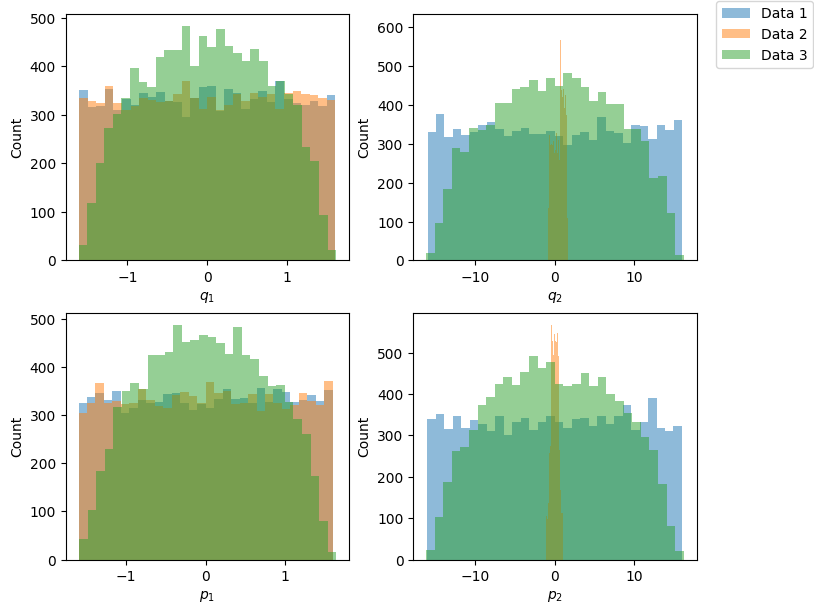

BoundingBox:	 mean(q1) = 0.0006636773244645171	 std(q1) = 0.9234077323624965
BoundingBox:	 mean(q2) = 0.006914263562627097	 std(q2) = 9.23652483423447
BoundingBox:	 mean(p1) = -0.00038578096273404066	 std(p1) = 0.9245564220242765
BoundingBox:	 mean(p2) = 0.0019517420259673743	 std(p2) = 9.243163264622241
BoundingBox-S:	 mean(q1) = 0.005707347788373844	 std(q1) = 0.9225727722174808
BoundingBox-S:	 mean(q2) = 0.467738272779929	 std(q2) = 0.671601559248432
BoundingBox-S:	 mean(p1) = -0.0007825591286013475	 std(p1) = 0.9220450490104634
BoundingBox-S:	 mean(p2) = 0.0003606765201534664	 std(p2) = 0.47491286923959447
HMC-H0:	 mean(q1) = 0.0012013468504649353	 std(q1) = 0.7556972807725557
HMC-H0:	 mean(q2) = 0.009846193589608287	 std(q2) = 7.534252681239601
HMC-H0:	 mean(p1) = 0.0009578654075949895	 std(p1) = 0.7529691549829101
HMC-H0:	 mean(p2) = 0.0019709064589170425	 std(p2) = 7.533775028142145


In [15]:
# Plot p and q histograms 
viz.plot_pq_density(
    [ds.random_samples(10000) for ds in datasets], 
    alpha=0.5,
    density=False,
    show_legend=True
)

for ds in datasets:
    p1, p2, q1, q2 = ds.states.get_pq()
    print(f"{ds.name}:\t mean(q1) = {q1.mean()}\t std(q1) = {q1.std()}")
    print(f"{ds.name}:\t mean(q2) = {q2.mean()}\t std(q2) = {q2.std()}")
    print(f"{ds.name}:\t mean(p1) = {p1.mean()}\t std(p1) = {p1.std()}")
    print(f"{ds.name}:\t mean(p2) = {p2.mean()}\t std(p2) = {p2.std()}")

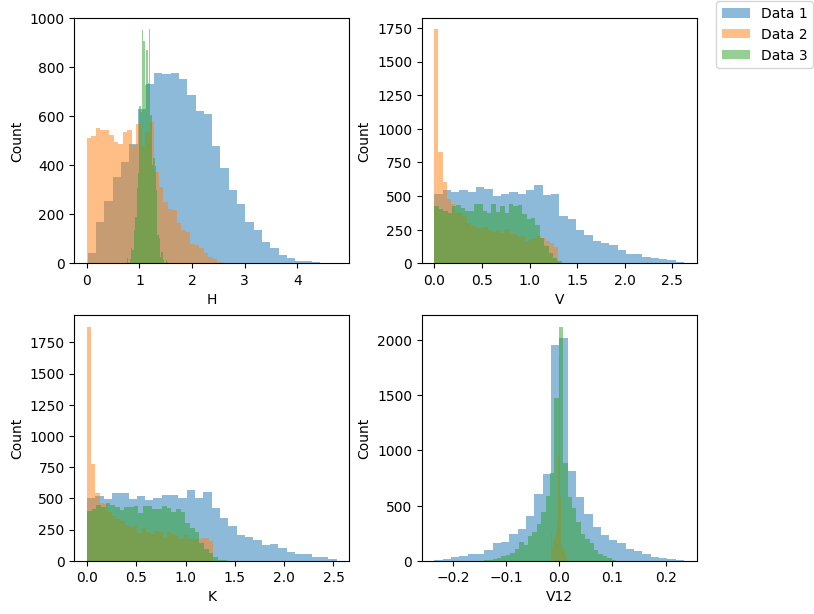

BoundingBox:	 mean(H) = 1.7076683288927426	 std(H) = 0.7655484890718957
BoundingBox:	 mean(V) = 0.8530856109973062	 std(V) = 0.5434642766481871
BoundingBox:	 mean(K) = 0.8545827178954366	 std(K) = 0.5396272561984293
BoundingBox:	 mean(V12) = 0.00017727656773326863	 std(V12) = 0.060020217458546986
BoundingBox-S:	 mean(H) = 0.8537379442360647	 std(H) = 0.5403156840298787
BoundingBox-S:	 mean(V) = 0.4275263900170314	 std(V) = 0.3819614617736228
BoundingBox-S:	 mean(K) = 0.4262115542190334	 std(K) = 0.3808760722583315
BoundingBox-S:	 mean(V12) = -0.0014092956419215368	 std(V12) = 0.005148973052966611
HMC-H0:	 mean(H) = 1.1338179998813611	 std(H) = 0.11596914967088984
HMC-H0:	 mean(V) = 0.5665474166548007	 std(V) = 0.334459703527662
HMC-H0:	 mean(K) = 0.567270583226561	 std(K) = 0.3344556850301291
HMC-H0:	 mean(V12) = -0.0028177971073161364	 std(V12) = 0.03322677243897434


In [16]:
# Plot histograms of computed functions
func_dict = {
    "H": processor.compute_hamiltonian,
    "V": processor.compute_potential_energy,
    "K": processor.compute_kinetic_energy,
    "V12": processor.compute_interaction_energy
}

viz.plot_density(
    [ds.random_samples(10000) for ds in datasets], 
    func_dict,
    alpha=0.5,
    density=False,
    show_legend=True
)

# Compute statistics
for ds in datasets:
    for key, func in func_dict.items():
        vals = func(ds.states.u)
        print(f"{ds.name}:\t mean({key}) = {vals.mean()}\t std({key}) = {vals.std()}")

In [17]:
# Prepare reference trajectories for comparison with the datasets

# Define trajectory indices (using constant energy trajectories)
ref_traj_indices = [1, 2, 3]

# Get reference trajectory filepaths
ref_filepaths = NCO.get_reference_filepaths("constant_energy")

# Load reference trajectories
ref_trajs = [
    Trajectory.load_from_file(
        ref_filepaths[epsilon][i]["filepath"], 
        dt=ref_filepaths[epsilon][i]["dt"],
        epsilon=epsilon,
    ) 
    for i in ref_traj_indices
]

for traj in ref_trajs:
    print(traj)

NCOTrajectory(t_range=[0.0, 2000.0], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(40001, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=0.05, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(40001, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=0.05, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(40001, 4)))


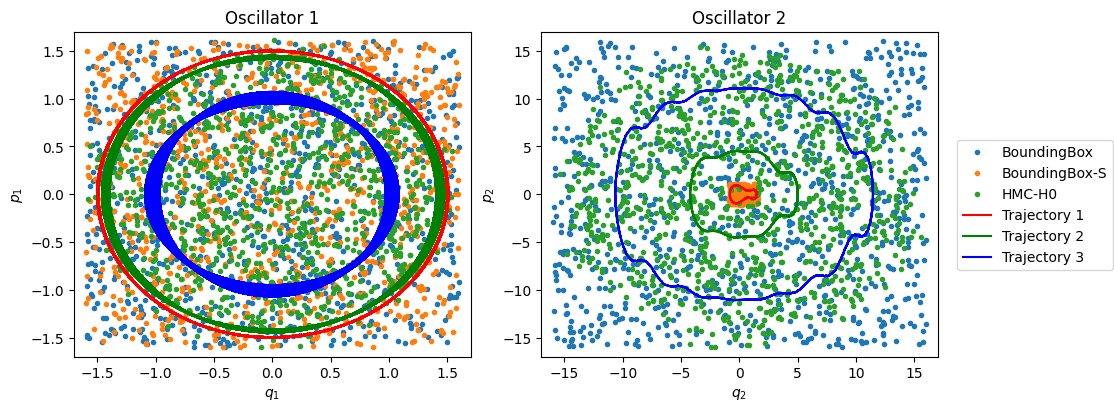

In [18]:
# Plot trajectories on top of datasets in the phase space
viz.plot_phase_space(
    [ds.random_samples(1000) for ds in datasets] + ref_trajs, 
    axis_lims=[((-1.7, 1.7), (-1.7, 1.7)), ((-17, 17), (-17, 17))], 
    linestyles=['.'] * len(datasets) + ['-'] * len(ref_trajs),
    alphas=[0.3] * len(datasets) + [1.] * len(ref_trajs),
    colors=list(colormaps.get_cmap('tab10').colors)[:3] + ['r', 'g', 'b'],
    legend_labels=[ds.name for ds in datasets] + [f"Trajectory {i}" for i in ref_traj_indices],
    show_legend=True,
    figsize=(11, 4)
)

### 3. Check if Data Distribution is Invariant Under the Flow

We verify that the distribution of HMC-$H_0$ samples remains invariant under time evolution.

In [19]:
# Load datasets at different time steps
Dt = 5e0
datadir = "../../data/nco/epsilon=1e-2/202510071037_rhmc-H0/Dt=5e0"

datasets = [Dataset.load_from_file(f"{datadir}/U{i}.csv", name=f"t={i*Dt}", epsilon=epsilon) for i in range(2)]
for ds in datasets:
    print(ds)

NCODataset(states=States(problem=NCO(epsilon=0.01), shape=(600000, 4)), name=t=0.0)
NCODataset(states=States(problem=NCO(epsilon=0.01), shape=(600000, 4)), name=t=5.0)


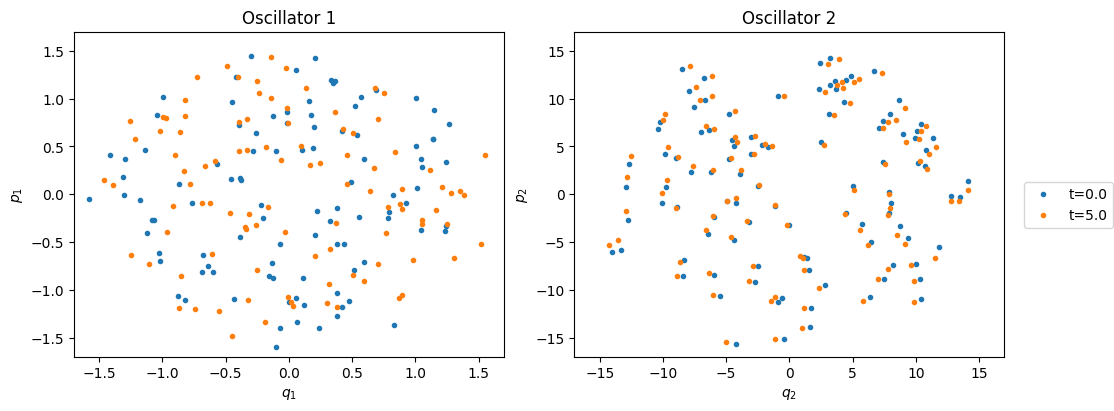

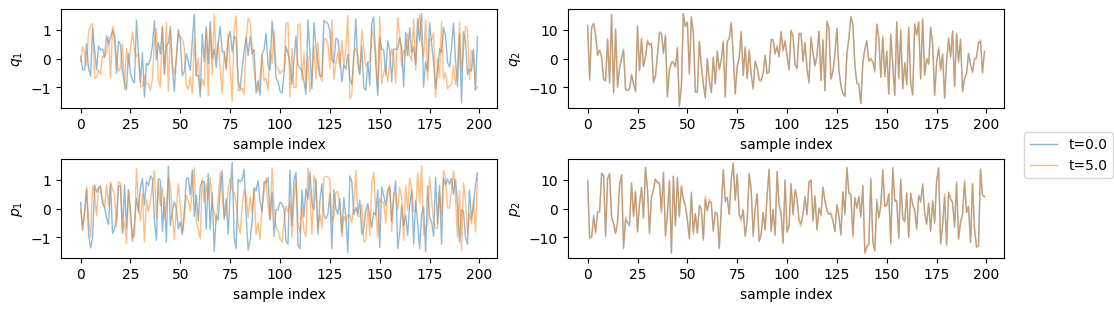

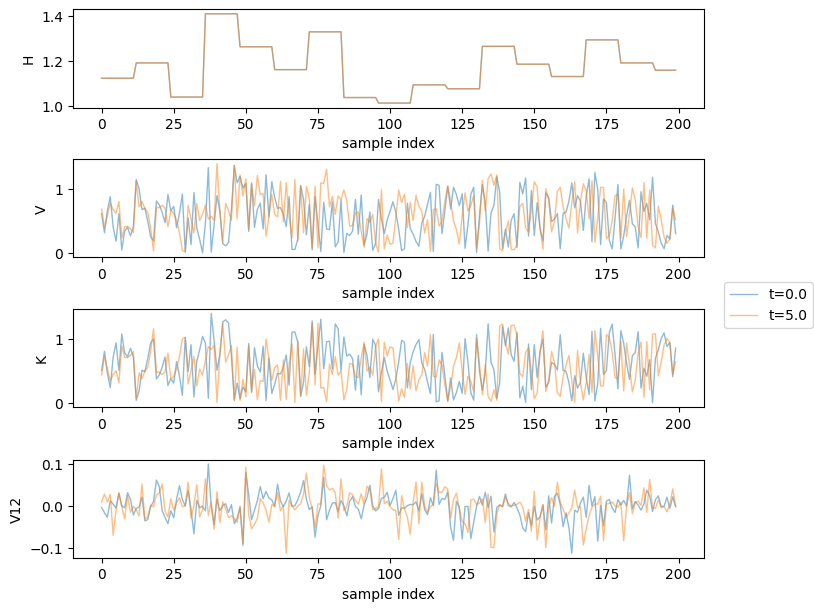

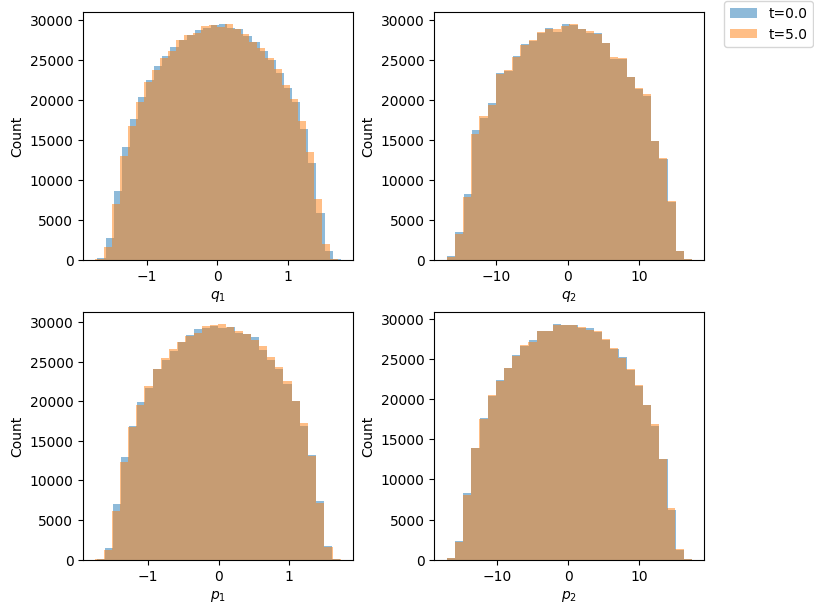

t=0.0:	 mean(q1) = 0.0012013468504649353	 std(q1) = 0.7556972807725557
t=0.0:	 mean(q2) = 0.009846193589608287	 std(q2) = 7.534252681239601
t=0.0:	 mean(p1) = 0.0009578654075949895	 std(p1) = 0.7529691549829101
t=0.0:	 mean(p2) = 0.0019709064589170425	 std(p2) = 7.533775028142145
t=5.0:	 mean(q1) = -0.0006512221980679364	 std(q1) = 0.7545794198022244
t=5.0:	 mean(q2) = 0.009952001148125979	 std(q2) = 7.535228146702601
t=5.0:	 mean(p1) = 0.0015038601973603929	 std(p1) = 0.7541122152853761
t=5.0:	 mean(p2) = 0.0021820359123771354	 std(p2) = 7.5327667236101945


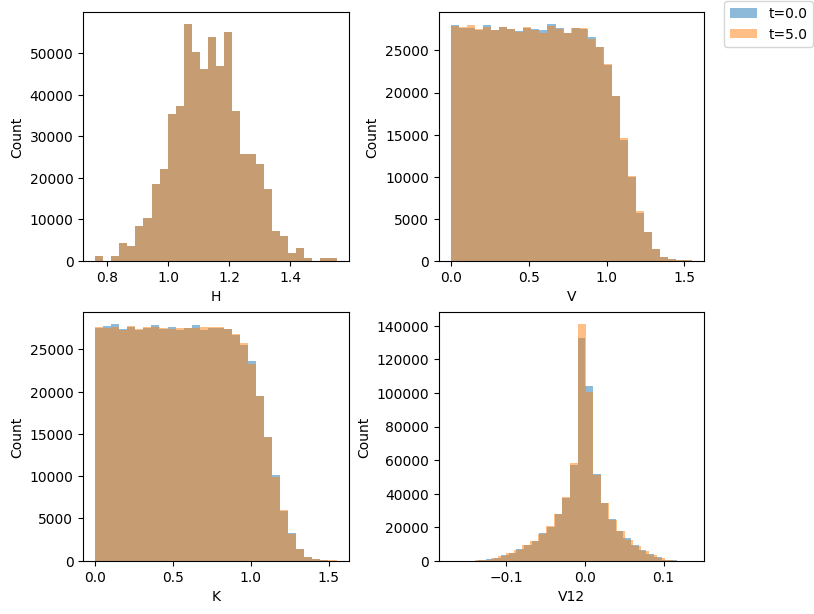

t=0.0:	 mean(H) = 1.1338179998813611	 std(H) = 0.11596914967088984
t=0.0:	 mean(V) = 0.5665474166548007	 std(V) = 0.334459703527662
t=0.0:	 mean(K) = 0.567270583226561	 std(K) = 0.3344556850301291
t=0.0:	 mean(V12) = -0.0028177971073161364	 std(V12) = 0.03322677243897434
t=5.0:	 mean(H) = 1.133817999881361	 std(H) = 0.11596914967088984
t=5.0:	 mean(V) = 0.5657613560942569	 std(V) = 0.33447778936417255
t=5.0:	 mean(K) = 0.568056643787104	 std(K) = 0.3345767203264636
t=5.0:	 mean(V12) = -0.0028327176713794644	 std(V12) = 0.033232347045944396


In [20]:
# Plot datasets in the phase space
viz.plot_phase_space(
    [ds.random_samples(100) for ds in datasets], 
    axis_lims=[((-1.7, 1.7), (-1.7, 1.7)), ((-17, 17), (-17, 17))], 
    alphas=0.3,
    legend_labels=[ds.name for ds in datasets],
    linestyles=['.'] * len(datasets),
    show_legend=True,
    figsize=(11, 4)
)

# Plot position and momentum vs sample index
viz.plot_pq_vs_t(
    [ds[:10000:50] for ds in datasets], 
    ylims=[(-1.7, 1.7), (-17, 17), (-1.7, 1.7), (-17, 17)], 
    alpha=0.5,
    legend_labels=[ds.name for ds in datasets],
    show_legend=True,
    xlabel='sample index',
    figsize=(11, 3)
)

# Plot traces of computed functions
viz.plot_history(
    [ds[:10000:50] for ds in datasets], 
    func_dict={
        "H": processor.compute_hamiltonian,
        "V": processor.compute_potential_energy,
        "K": processor.compute_kinetic_energy,
        "V12": processor.compute_interaction_energy
    },
    alpha=0.5,
    legend_labels=[ds.name for ds in datasets],
    show_legend=True,
    xlabel='sample index'
)

# Plot position and momentum histograms 
viz.plot_pq_density(
    datasets, 
    alpha=0.5,
    density=False,
    legend_labels=[ds.name for ds in datasets],
    show_legend=True
)

# Compute statistics
for ds in datasets:
    p1, p2, q1, q2 = ds.states.get_pq()
    print(f"{ds.name}:\t mean(q1) = {q1.mean()}\t std(q1) = {q1.std()}")
    print(f"{ds.name}:\t mean(q2) = {q2.mean()}\t std(q2) = {q2.std()}")
    print(f"{ds.name}:\t mean(p1) = {p1.mean()}\t std(p1) = {p1.std()}")
    print(f"{ds.name}:\t mean(p2) = {p2.mean()}\t std(p2) = {p2.std()}")

# Plot histograms of computed functions
func_dict = {
    "H": processor.compute_hamiltonian,
    "V": processor.compute_potential_energy,
    "K": processor.compute_kinetic_energy,
    "V12": processor.compute_interaction_energy
}

viz.plot_density(
    datasets, 
    func_dict=func_dict,
    alpha=0.5,
    density=False,
    legend_labels=[ds.name for ds in datasets],
    show_legend=True
)

# Compute statistics
for ds in datasets:
    for key, func in func_dict.items():
        vals = func(ds.states.u)
        print(f"{ds.name}:\t mean({key}) = {vals.mean()}\t std({key}) = {vals.std()}")

In [21]:
# Custom function to plot MMD vs time
def plot_mmd_vs_t(datadirs, Dt, K, epsilon, select_interval=50, figsize=(5, 3), ylim=None, alpha=1.0, 
                  legend_labels=None, show_legend=True, title=None, save_path=None):
    """Plot Maximum Mean Discrepancy (MMD) between datasets at different times."""
    
    if legend_labels is None:
        legend_labels = list(datadirs.keys())  # Default labels for legends
    
    fig, ax = plt.subplots(1, 1, figsize=figsize, layout='constrained')

    for datadir, label in zip(datadirs.values(), legend_labels):
        datasets = [Dataset.load_from_file(f"{datadir}/U{i}.csv", name=f"t={i*Dt}", epsilon=epsilon) for i in range(K+1)]
        idx = np.arange(len(datasets[0]))[::select_interval]
        mmds = [Dataset.mmd(ds[idx], datasets[0][idx]) for ds in datasets]
        ax.plot(np.arange(K+1)*Dt, mmds, ".-", alpha=alpha, label=label)
    
    if ylim is not None:
        ax.set_ylim(ylim)
    
    ax.set_xlabel("t")
    ax.set_ylabel("MMD")

    if title is not None:
        ax.set_title(title)

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(legend_labels, loc='outside center right', borderaxespad=0.1)

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


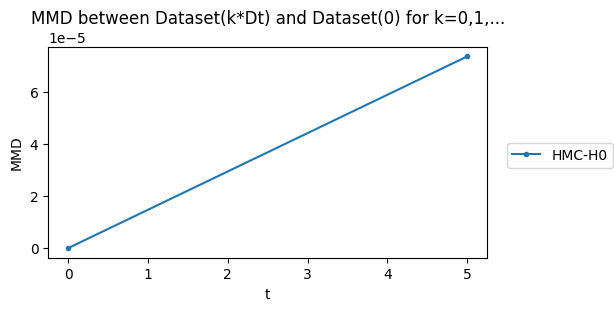

In [25]:
# Plot MMD vs time for different datasets
datadirs = {
    # "BoundingBox": "../../data/nco/epsilon=1e-2/202510080010_box/Dt=5e0",
    "HMC-H0": "../../data/nco/epsilon=1e-2/202510071037_rhmc-H0/Dt=5e0",
}

plot_mmd_vs_t(datadirs, 5e0, 1, epsilon,
              figsize=(6, 3), 
              title="MMD between Dataset(k*Dt) and Dataset(0) for k=0,1,...")